# Amazon E-Commerce Sales Analytics

## 07 — Seller Analysis

### Objective

The objective of this notebook is to evaluate seller-level performance using the cleaned e-commerce transaction dataset.

The analysis focuses on:

- Seller order volume
- Seller sales performance
- Units sold
- Average order value
- Average unit price
- Discount behavior
- Customer reach
- Product and category diversity
- Order-status performance
- Seller performance tiers
- Seller concentration
- Top and bottom sellers by business metrics
- Category performance by seller
- Business insights and recommendations

### Important Dataset Note

The dataset contains a `SellerID` field but does not contain a separate seller name, seller rating, seller cost, commission, or profit field.

Therefore, sellers are identified using `SellerID`.

This notebook evaluates **observed sales performance**, not seller profitability or seller quality.


### Key Business Questions

1. How many sellers are represented in the dataset?
2. Which sellers generate the highest sales?
3. Which sellers process the most orders?
4. Which sellers sell the most units?
5. Which sellers have the highest average order value?
6. Which sellers offer the highest average discounts?
7. Which sellers reach the most customers?
8. Which sellers have the widest product and category coverage?
9. Which sellers have the highest delivery rate?
10. Which sellers have the highest cancellation rate?
11. How concentrated are sales among the top sellers?
12. Which sellers perform strongly across multiple business metrics?
13. Which categories contribute most to seller sales?
14. What business actions can be derived from seller-level performance?


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# Load the cleaned dataset

file_path = "C:/Users/Hp/OneDrive/Desktop/Projects/Amazon E-Commerce Sales Performance & Customer Analytics/Data/Amazon_Cleaned.csv"

df = pd.read_csv(file_path)

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (100000, 25)


In [3]:
# Confirm seller-analysis fields

required_columns = [
    "OrderID",
    "OrderDate",
    "CustomerID",
    "ProductID",
    "ProductName",
    "Category",
    "Brand",
    "Quantity",
    "UnitPrice",
    "Discount",
    "Tax",
    "ShippingCost",
    "TotalAmount",
    "PaymentMethod",
    "OrderStatus",
    "SellerID"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required seller-analysis columns are available.")


All required seller-analysis columns are available.


## 1. Seller-Level Derived Metrics

The seller analysis uses the following transaction-level measures:

- **Gross Product Value** = `Quantity × UnitPrice`
- **Discount Amount** = `Gross Product Value × Discount`
- **Net Product Sales** = `Gross Product Value − Discount Amount`
- **Effective Unit Price** = `UnitPrice × (1 − Discount)`

These measures are consistent with Notebook 6 so that seller results remain comparable with the discount and pricing analysis.


In [4]:
# Create seller-analysis metrics

df["GrossProductValue"] = df["Quantity"] * df["UnitPrice"]

df["DiscountAmount"] = (
    df["GrossProductValue"] * df["Discount"]
)

df["NetProductSales"] = (
    df["GrossProductValue"] - df["DiscountAmount"]
)

df["EffectiveUnitPrice"] = (
    df["UnitPrice"] * (1 - df["Discount"])
)

df["DiscountPercent"] = df["Discount"] * 100

df[
    [
        "SellerID",
        "Quantity",
        "UnitPrice",
        "Discount",
        "GrossProductValue",
        "DiscountAmount",
        "NetProductSales",
        "TotalAmount"
    ]
].head()


,SellerID,Quantity,UnitPrice,Discount,GrossProductValue,DiscountAmount,NetProductSales,TotalAmount
0,SELL01967,3,106.59,0.00,319.77,0.0000,319.7700,319.86
1,SELL01298,1,251.37,0.05,251.37,12.5685,238.8015,259.64
2,SELL00908,3,35.03,0.10,105.09,10.5090,94.5810,108.06
3,SELL01164,5,33.58,0.15,167.90,25.1850,142.7150,159.66
4,SELL01411,2,515.64,0.25,1031.28,257.8200,773.4600,821.36


## 2. Overall Seller Overview

Before ranking individual sellers, the overall seller population and transaction coverage are summarized.


In [5]:
seller_overview = pd.DataFrame({
    "Metric": [
        "Unique Sellers",
        "Total Orders",
        "Total Units Sold",
        "Total Net Product Sales",
        "Average Seller Sales",
        "Median Seller Sales",
        "Average Orders per Seller",
        "Average Units per Seller"
    ],
    "Value": [
        df["SellerID"].nunique(),
        df["OrderID"].nunique(),
        df["Quantity"].sum(),
        df["NetProductSales"].sum(),
        df.groupby("SellerID")["NetProductSales"].sum().mean(),
        df.groupby("SellerID")["NetProductSales"].sum().median(),
        df.groupby("SellerID")["OrderID"].nunique().mean(),
        df.groupby("SellerID")["Quantity"].sum().mean()
    ]
})

seller_overview


,Metric,Value
0,Unique Sellers,1.999000e+03
1,Total Orders,1.000000e+05
2,Total Units Sold,3.001400e+05
3,Total Net Product Sales,8.423809e+07
4,Average Seller Sales,4.214012e+04
5,Median Seller Sales,4.185932e+04
6,Average Orders per Seller,5.002501e+01
7,Average Units per Seller,1.501451e+02


## 3. Seller Performance Summary

This is the main seller-level summary table. It combines sales, volume, customer reach, pricing, discounting, and product coverage.


In [6]:
seller_summary = (
    df.groupby("SellerID")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustomerID", "nunique"),
          Products=("ProductID", "nunique"),
          Product_Names=("ProductName", "nunique"),
          Categories=("Category", "nunique"),
          Brands=("Brand", "nunique"),
          Units=("Quantity", "sum"),
          GrossProductValue=("GrossProductValue", "sum"),
          DiscountAmount=("DiscountAmount", "sum"),
          NetProductSales=("NetProductSales", "sum"),
          TotalOrderValue=("TotalAmount", "sum"),
          Average_Order_Value=("TotalAmount", "mean"),
          Average_Unit_Price=("UnitPrice", "mean"),
          Average_Discount=("Discount", "mean"),
          Average_Effective_Price=("EffectiveUnitPrice", "mean")
      )
      .reset_index()
)

seller_summary["Weighted_Discount_%"] = (
    seller_summary["DiscountAmount"]
    / seller_summary["GrossProductValue"]
    * 100
)

seller_summary["Sales_Share_%"] = (
    seller_summary["NetProductSales"]
    / seller_summary["NetProductSales"].sum()
    * 100
)

seller_summary["Units_Share_%"] = (
    seller_summary["Units"]
    / seller_summary["Units"].sum()
    * 100
)

seller_summary = seller_summary.sort_values(
    "NetProductSales",
    ascending=False
)

seller_summary.head(15)


,SellerID,Orders,Customers,Products,Product_Names,Categories,Brands,Units,GrossProductValue,DiscountAmount,NetProductSales,TotalOrderValue,Average_Order_Value,Average_Unit_Price,Average_Discount,Average_Effective_Price,Weighted_Discount_%,Sales_Share_%,Units_Share_%
805,SELL00806,67,67,37,37,6,10,234,70146.50,4312.2920,65834.2080,71283.67,1063.935373,295.584179,0.067910,276.845358,6.147551,0.078153,0.077964
439,SELL00440,61,61,34,34,6,10,197,70413.19,4945.2370,65467.9530,71062.59,1164.960492,341.693115,0.067213,317.768393,7.023169,0.077718,0.065636
220,SELL00221,65,65,37,37,6,10,211,69719.18,4973.0240,64746.1560,70446.50,1083.792308,332.814308,0.064615,310.529438,7.132935,0.076861,0.070301
1121,SELL01122,67,67,37,37,6,10,217,70286.91,5960.1275,64326.7825,69469.40,1036.856716,311.865970,0.085075,284.798993,8.479712,0.076363,0.072300
1224,SELL01225,61,61,37,37,6,9,204,68018.29,3795.9640,64222.3260,70785.92,1160.424918,328.983279,0.054098,310.330877,5.580799,0.076239,0.067968
708,SELL00709,69,69,39,39,6,10,223,69336.24,5215.3095,64120.9305,70491.92,1021.622029,318.983768,0.070290,296.993594,7.521766,0.076119,0.074299
811,SELL00812,68,68,36,36,6,10,212,68103.26,4280.0675,63823.1925,68591.86,1008.703824,318.350882,0.060294,298.345250,6.284673,0.075765,0.070634
993,SELL00994,61,61,35,35,6,10,199,69632.73,5950.0015,63682.7285,69400.06,1137.705902,341.440328,0.085246,313.529295,8.544834,0.075598,0.066302
535,SELL00536,70,70,39,39,6,10,220,68324.63,5179.4410,63145.1890,69248.00,989.257143,296.888143,0.079286,275.749650,7.580635,0.074960,0.073299
1921,SELL01922,66,66,38,38,6,10,204,68200.29,5456.6525,62743.6375,68290.28,1034.701212,335.873333,0.079545,309.506962,8.000923,0.074484,0.067968


## 4. Top Sellers by Net Product Sales

Net Product Sales is used as the primary sales-performance metric because it reflects product value after the recorded discount while excluding tax and shipping from the product-sales measure.


In [7]:
top_sellers_sales = (
    seller_summary
    .sort_values("NetProductSales", ascending=False)
    .head(15)
)

top_sellers_sales[
    [
        "SellerID",
        "Orders",
        "Units",
        "Customers",
        "NetProductSales",
        "Sales_Share_%",
        "Weighted_Discount_%"
    ]
]


,SellerID,Orders,Units,Customers,NetProductSales,Sales_Share_%,Weighted_Discount_%
805,SELL00806,67,234,67,65834.2080,0.078153,6.147551
439,SELL00440,61,197,61,65467.9530,0.077718,7.023169
220,SELL00221,65,211,65,64746.1560,0.076861,7.132935
1121,SELL01122,67,217,67,64326.7825,0.076363,8.479712
1224,SELL01225,61,204,61,64222.3260,0.076239,5.580799
708,SELL00709,69,223,69,64120.9305,0.076119,7.521766
811,SELL00812,68,212,68,63823.1925,0.075765,6.284673
993,SELL00994,61,199,61,63682.7285,0.075598,8.544834
535,SELL00536,70,220,70,63145.1890,0.074960,7.580635
1921,SELL01922,66,204,66,62743.6375,0.074484,8.000923


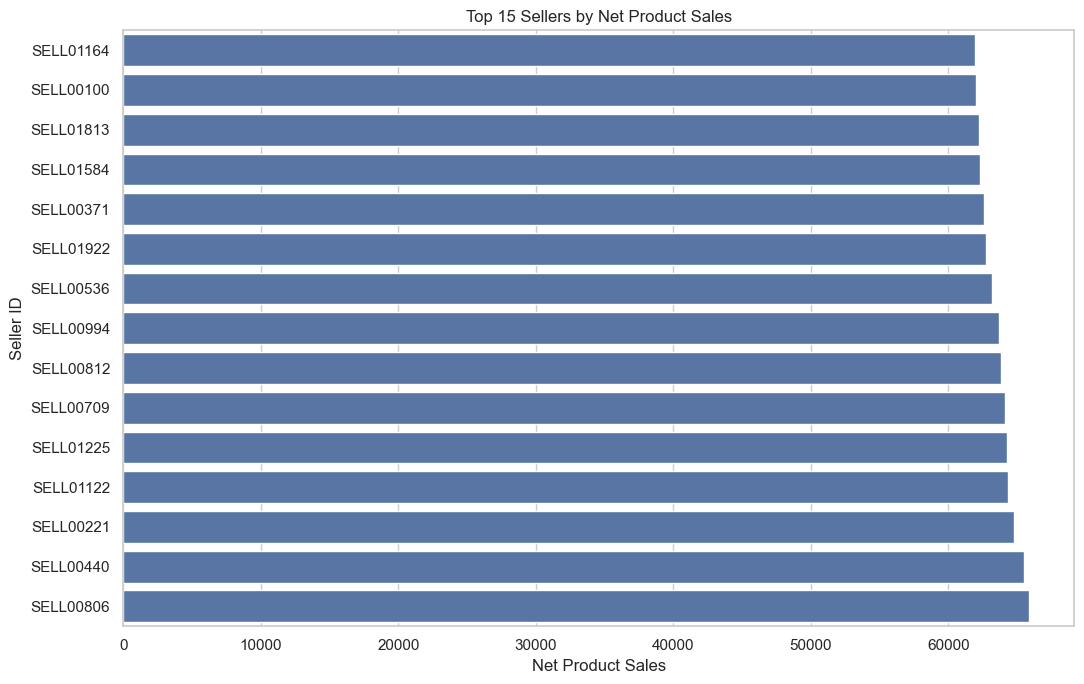

In [8]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_sellers_sales.sort_values("NetProductSales"),
    x="NetProductSales",
    y="SellerID"
)

plt.title("Top 15 Sellers by Net Product Sales")
plt.xlabel("Net Product Sales")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()


### Interpretation

This ranking identifies the sellers contributing the largest amount of net product sales.

A high-sales seller should not automatically be considered the best seller because sales volume alone does not capture customer reach, order volume, delivery performance, discount intensity, or product diversity.


## 5. Top Sellers by Order Volume

Order count measures transaction activity rather than monetary value.


In [9]:
top_sellers_orders = (
    seller_summary
    .sort_values("Orders", ascending=False)
    .head(15)
)

top_sellers_orders[
    [
        "SellerID",
        "Orders",
        "NetProductSales",
        "Units",
        "Customers",
        "Average_Order_Value"
    ]
]


,SellerID,Orders,NetProductSales,Units,Customers,Average_Order_Value
1098,SELL01099,78,56626.0940,230,78,789.272179
1334,SELL01335,71,58474.0190,205,71,891.345352
791,SELL00792,71,60807.5175,224,71,938.251549
1446,SELL01447,70,50742.6190,206,69,799.884714
535,SELL00536,70,63145.1890,220,70,989.257143
875,SELL00876,69,55376.8220,188,69,877.269855
708,SELL00709,69,64120.9305,223,69,1021.622029
1583,SELL01584,69,62315.1155,213,69,983.517681
1240,SELL01241,68,59958.4410,214,68,954.738971
811,SELL00812,68,63823.1925,212,68,1008.703824


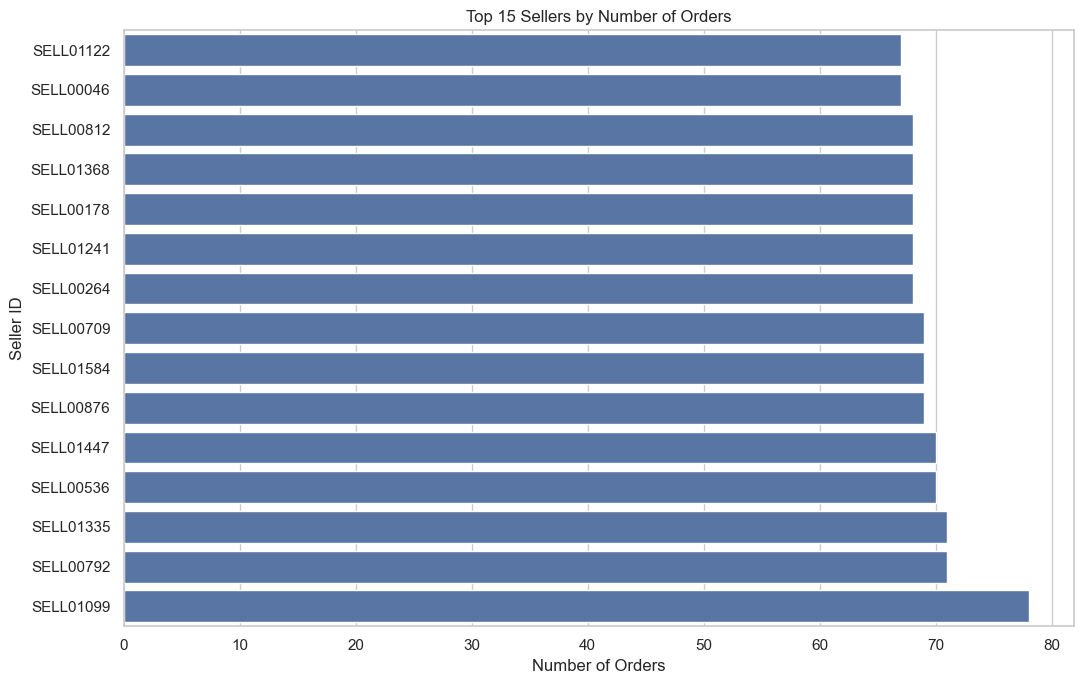

In [10]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_sellers_orders.sort_values("Orders"),
    x="Orders",
    y="SellerID"
)

plt.title("Top 15 Sellers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()


## 6. Top Sellers by Units Sold

Units sold indicates product volume and helps distinguish high-value sellers from high-volume sellers.


In [11]:
top_sellers_units = (
    seller_summary
    .sort_values("Units", ascending=False)
    .head(15)
)

top_sellers_units[
    [
        "SellerID",
        "Units",
        "Orders",
        "NetProductSales",
        "Customers",
        "Average_Order_Value"
    ]
]


,SellerID,Units,Orders,NetProductSales,Customers,Average_Order_Value
805,SELL00806,234,67,65834.2080,67,1063.935373
1098,SELL01099,230,78,56626.0940,78,789.272179
791,SELL00792,224,71,60807.5175,71,938.251549
708,SELL00709,223,69,64120.9305,69,1021.622029
1367,SELL01368,220,68,59276.4975,68,946.336471
535,SELL00536,220,70,63145.1890,70,989.257143
1121,SELL01122,217,67,64326.7825,67,1036.856716
1240,SELL01241,214,68,59958.4410,68,954.738971
346,SELL00347,213,67,55740.4550,67,905.592388
1583,SELL01584,213,69,62315.1155,69,983.517681


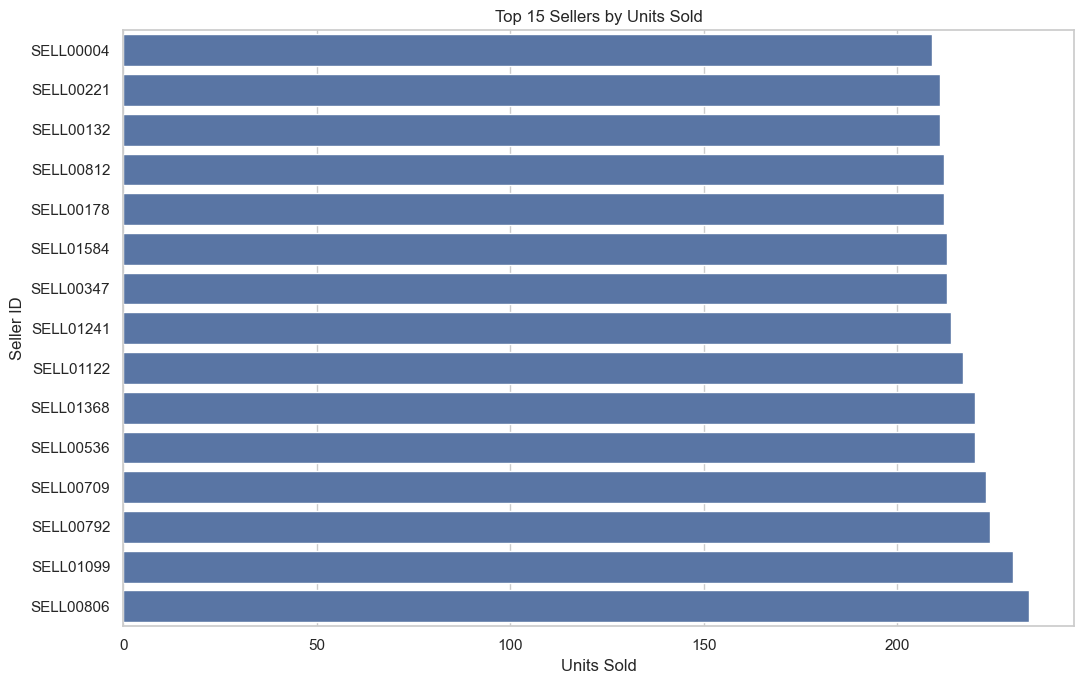

In [12]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_sellers_units.sort_values("Units"),
    x="Units",
    y="SellerID"
)

plt.title("Top 15 Sellers by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()


## 7. Seller Customer Reach

Customer reach measures how many distinct customers purchased from each seller.

A seller with many customers may have broader market reach, while a seller with fewer customers but high sales may have a higher-value transaction mix.


In [13]:
top_customer_reach = (
    seller_summary
    .sort_values("Customers", ascending=False)
    .head(15)
)

top_customer_reach[
    [
        "SellerID",
        "Customers",
        "Orders",
        "NetProductSales",
        "Units"
    ]
]


,SellerID,Customers,Orders,NetProductSales,Units
1098,SELL01099,78,78,56626.0940,230
1334,SELL01335,71,71,58474.0190,205
791,SELL00792,71,71,60807.5175,224
535,SELL00536,70,70,63145.1890,220
875,SELL00876,69,69,55376.8220,188
708,SELL00709,69,69,64120.9305,223
1446,SELL01447,69,70,50742.6190,206
1583,SELL01584,69,69,62315.1155,213
1367,SELL01368,68,68,59276.4975,220
263,SELL00264,68,68,55600.8405,204


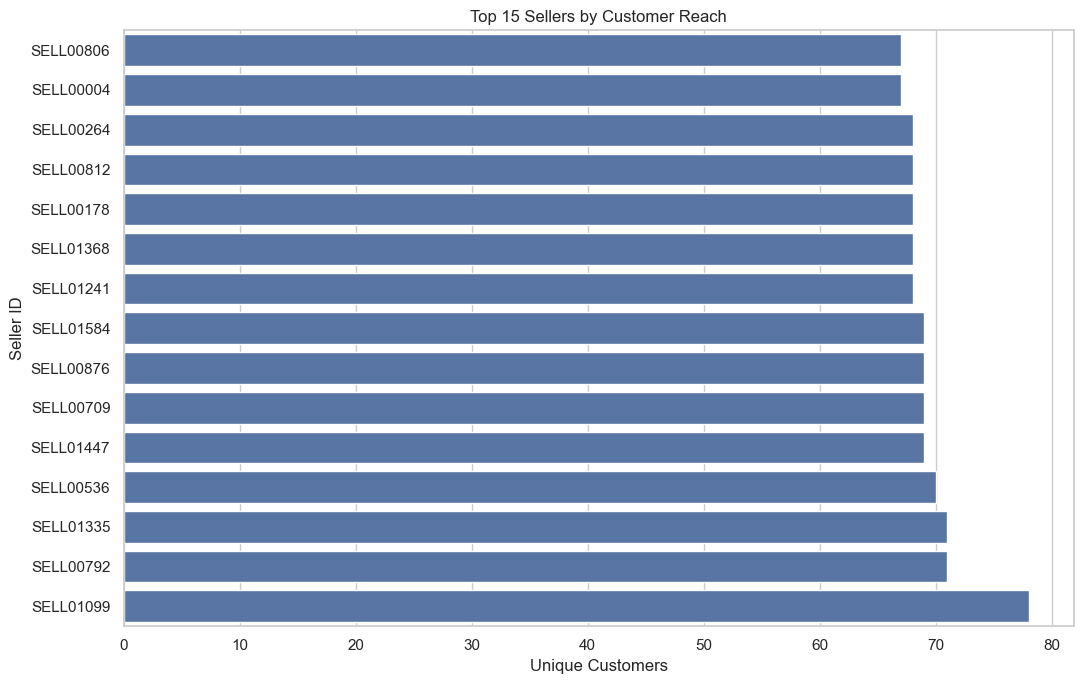

In [14]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_customer_reach.sort_values("Customers"),
    x="Customers",
    y="SellerID"
)

plt.title("Top 15 Sellers by Customer Reach")
plt.xlabel("Unique Customers")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()


## 8. Average Order Value by Seller

Average order value helps identify sellers whose transactions tend to have higher monetary value.

Because `TotalAmount` includes tax and shipping, this metric represents recorded order value rather than pure product revenue.


In [15]:
top_aov_sellers = (
    seller_summary
    .sort_values("Average_Order_Value", ascending=False)
    .head(15)
)

top_aov_sellers[
    [
        "SellerID",
        "Average_Order_Value",
        "Orders",
        "NetProductSales",
        "Units"
    ]
]


,SellerID,Average_Order_Value,Orders,NetProductSales,Units
341,SELL00342,1231.023000,50,56366.0300,173
931,SELL00932,1224.059583,48,53381.0715,164
719,SELL00720,1215.368409,44,49074.9495,148
1424,SELL01425,1213.781818,55,61234.3285,185
430,SELL00431,1206.895128,39,42590.8015,129
1553,SELL01554,1191.620217,46,50705.2330,145
586,SELL00587,1186.635319,47,51179.7480,142
521,SELL00522,1186.531400,50,53975.2125,172
1930,SELL01931,1184.993958,48,52883.4435,150
608,SELL00609,1177.032500,52,56421.7520,168


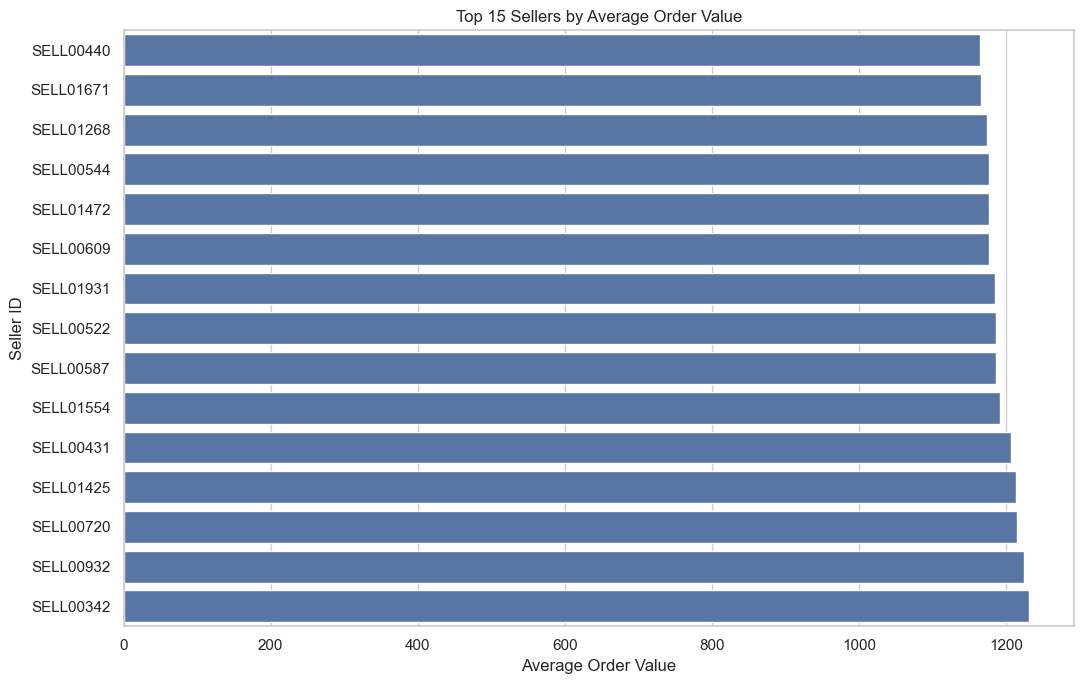

In [16]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_aov_sellers.sort_values("Average_Order_Value"),
    x="Average_Order_Value",
    y="SellerID"
)

plt.title("Top 15 Sellers by Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()


## 9. Seller Discount Behavior

This section compares sellers by weighted discount rate.

A high seller discount rate indicates that a larger share of gross product value was discounted in that seller's transactions.

It does not indicate profitability because seller cost data is unavailable.


In [17]:
top_discount_sellers = (
    seller_summary
    .sort_values("Weighted_Discount_%", ascending=False)
    .head(15)
)

top_discount_sellers[
    [
        "SellerID",
        "Weighted_Discount_%",
        "DiscountAmount",
        "GrossProductValue",
        "NetProductSales",
        "Orders"
    ]
]


,SellerID,Weighted_Discount_%,DiscountAmount,GrossProductValue,NetProductSales,Orders
1746,SELL01747,13.824233,6021.0465,43554.29,37533.2435,48
1515,SELL01516,13.264305,5157.7985,38884.80,33727.0015,44
235,SELL00236,12.883936,6595.1080,51188.61,44593.5020,50
414,SELL00415,12.699199,6441.8845,50726.70,44284.8155,47
712,SELL00713,12.480256,5698.4810,45659.97,39961.4890,56
8,SELL00009,12.342876,4165.8860,33751.34,29585.4540,33
79,SELL00080,12.214820,4181.1365,34230.03,30048.8935,49
481,SELL00482,12.038735,5070.1975,42115.70,37045.5025,46
1938,SELL01939,11.854265,3896.8205,32872.73,28975.9095,42
253,SELL00254,11.843559,4959.1755,41872.34,36913.1645,45


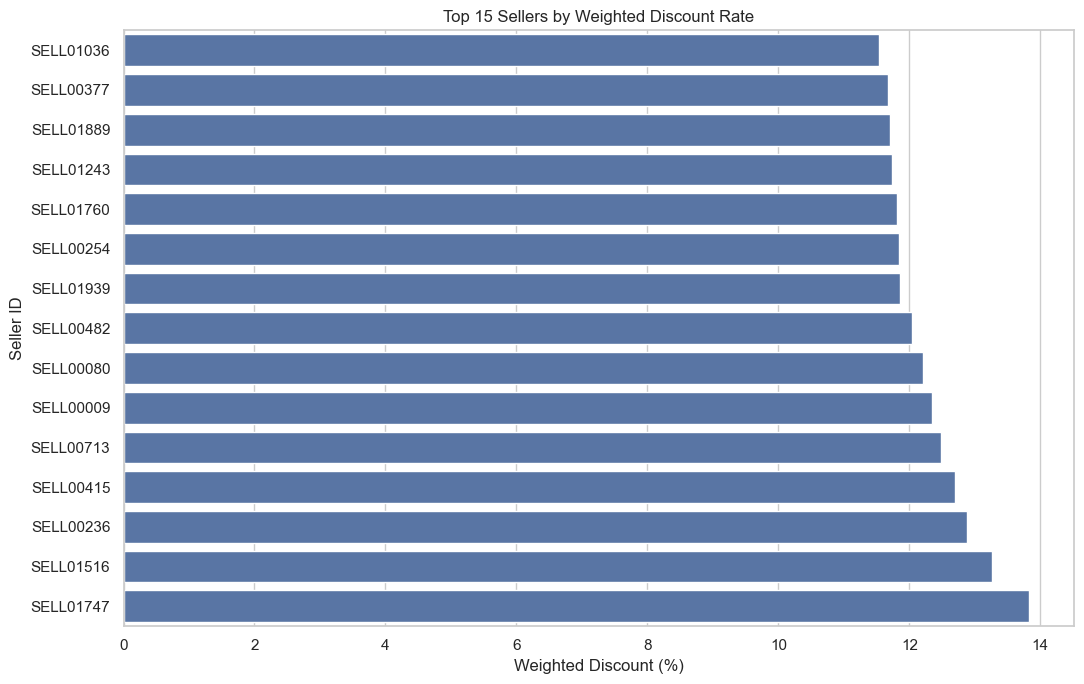

In [18]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_discount_sellers.sort_values("Weighted_Discount_%"),
    x="Weighted_Discount_%",
    y="SellerID"
)

plt.title("Top 15 Sellers by Weighted Discount Rate")
plt.xlabel("Weighted Discount (%)")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()


## 10. Seller Product & Category Diversity

Product and category diversity provides context for seller scale.

A seller with broad product coverage may have a different business model from a specialist seller focused on a small number of categories.


In [19]:
seller_diversity = (
    seller_summary[
        [
            "SellerID",
            "Products",
            "Categories",
            "Brands",
            "NetProductSales",
            "Orders",
            "Units"
        ]
    ]
    .sort_values(
        ["Categories", "Products"],
        ascending=[False, False]
    )
)

seller_diversity.head(15)


,SellerID,Products,Categories,Brands,NetProductSales,Orders,Units
263,SELL00264,44,6,10,55600.8405,68,204
441,SELL00442,43,6,10,42276.0260,57,164
1197,SELL01198,41,6,10,45896.7015,58,153
626,SELL00627,41,6,10,41604.3520,62,176
1240,SELL01241,40,6,10,59958.4410,68,214
1334,SELL01335,40,6,10,58474.0190,71,205
809,SELL00810,40,6,10,47574.4835,58,169
9,SELL00010,40,6,10,41536.4305,59,171
708,SELL00709,39,6,10,64120.9305,69,223
535,SELL00536,39,6,10,63145.1890,70,220


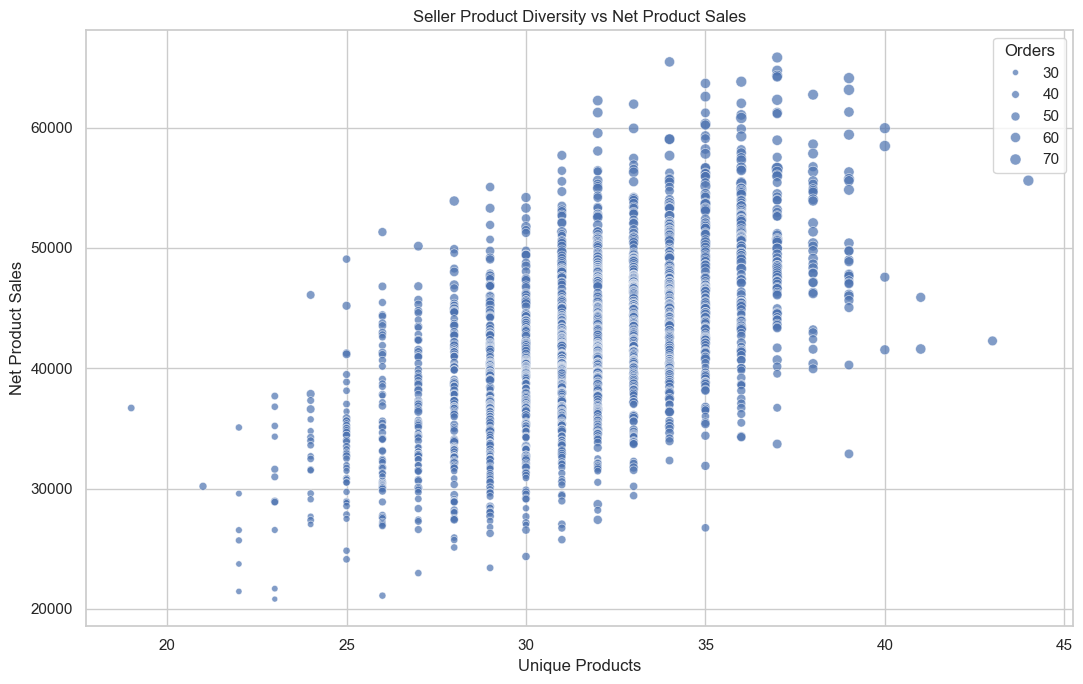

In [20]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=seller_summary,
    x="Products",
    y="NetProductSales",
    size="Orders",
    alpha=0.7
)

plt.title("Seller Product Diversity vs Net Product Sales")
plt.xlabel("Unique Products")
plt.ylabel("Net Product Sales")

plt.tight_layout()
plt.show()


## 11. Order Status Performance

Seller performance is also evaluated by order status.

The dataset's `OrderStatus` values are used directly rather than assuming a fixed status vocabulary.


In [21]:
order_status_values = (
    df["OrderStatus"]
    .value_counts(dropna=False)
    .rename_axis("OrderStatus")
    .reset_index(name="Orders")
)

order_status_values


,OrderStatus,Orders
0,Delivered,74628
1,Shipped,15192
2,Pending,4103
3,Returned,3049
4,Cancelled,3028


In [22]:
seller_status = pd.crosstab(
    df["SellerID"],
    df["OrderStatus"]
)

seller_status.head()


OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
SellerID,,,,,
SELL00001,0,34,6,2,17
SELL00002,0,44,1,0,8
SELL00003,1,41,2,0,7
SELL00004,1,50,4,3,9
SELL00005,1,38,1,2,6


In [23]:
# Create seller-level status metrics

status_counts = (
    df.pivot_table(
        index="SellerID",
        columns="OrderStatus",
        values="OrderID",
        aggfunc="nunique",
        fill_value=0
    )
)

status_counts["Total_Orders"] = status_counts.sum(axis=1)

status_counts


OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped,Total_Orders
SellerID,,,,,,
SELL00001,0,34,6,2,17,59
SELL00002,0,44,1,0,8,53
SELL00003,1,41,2,0,7,51
SELL00004,1,50,4,3,9,67
SELL00005,1,38,1,2,6,48
...,...,...,...,...,...,...
SELL01995,1,42,3,1,3,50
SELL01996,1,43,0,0,5,49
SELL01997,0,45,2,2,3,52


## 12. Seller Delivery Rate

If the dataset contains a `Delivered` status, delivery rate is calculated as delivered orders divided by total orders.

If other statuses exist, they remain visible in the seller status table and are not silently reclassified.


In [24]:
seller_status_performance = status_counts.copy()

if "Delivered" in seller_status_performance.columns:
    seller_status_performance["Delivery_Rate_%"] = (
        seller_status_performance["Delivered"]
        / seller_status_performance["Total_Orders"]
        * 100
    )
else:
    seller_status_performance["Delivery_Rate_%"] = np.nan

if "Cancelled" in seller_status_performance.columns:
    seller_status_performance["Cancellation_Rate_%"] = (
        seller_status_performance["Cancelled"]
        / seller_status_performance["Total_Orders"]
        * 100
    )
else:
    seller_status_performance["Cancellation_Rate_%"] = np.nan

seller_status_performance = (
    seller_status_performance
    .reset_index()
    .sort_values("Delivery_Rate_%", ascending=False)
)

seller_status_performance.head(15)


OrderStatus,SellerID,Cancelled,Delivered,Pending,Returned,Shipped,Total_Orders,Delivery_Rate_%,Cancellation_Rate_%
669,SELL00670,0,47,0,1,1,49,95.918367,0.000000
1916,SELL01917,1,47,1,1,1,51,92.156863,1.960784
1846,SELL01847,2,45,1,0,1,49,91.836735,4.081633
586,SELL00587,0,43,2,0,2,47,91.489362,0.000000
1808,SELL01809,1,50,0,1,3,55,90.909091,1.818182
1337,SELL01338,0,50,0,1,4,55,90.909091,0.000000
1134,SELL01135,0,50,1,2,2,55,90.909091,0.000000
526,SELL00527,0,36,0,0,4,40,90.000000,0.000000
42,SELL00043,0,43,2,0,3,48,89.583333,0.000000
890,SELL00891,1,34,0,0,3,38,89.473684,2.631579


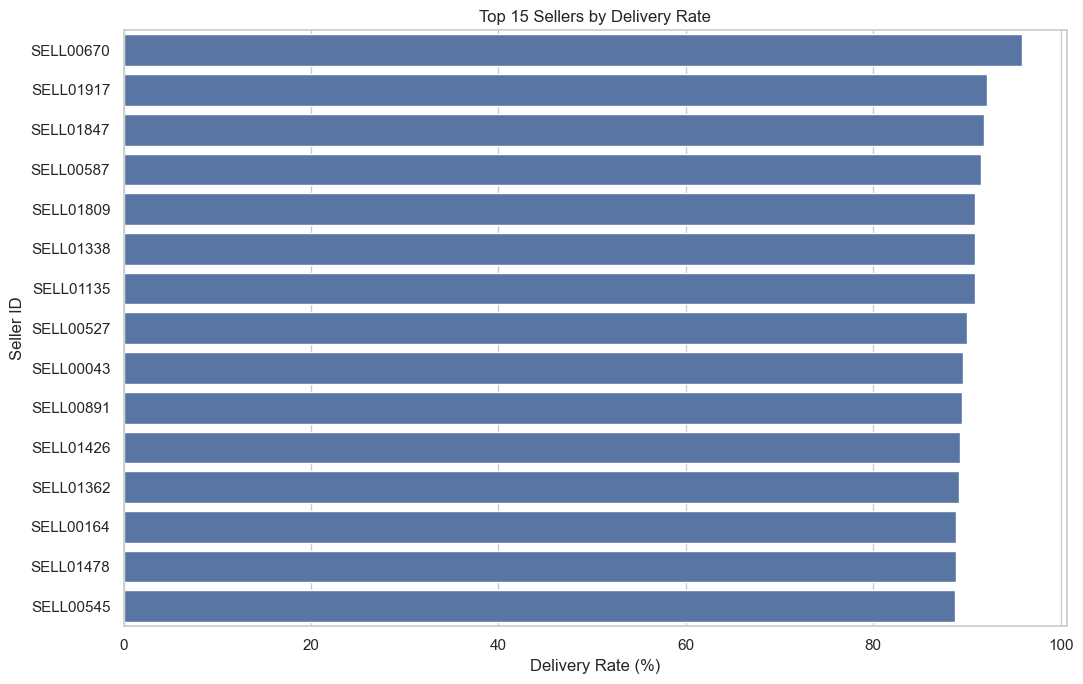

In [25]:
if seller_status_performance["Delivery_Rate_%"].notna().any():
    plt.figure(figsize=(11, 7))

    plot_data = (
        seller_status_performance
        .sort_values("Delivery_Rate_%", ascending=False)
        .head(15)
    )

    sns.barplot(
        data=plot_data,
        x="Delivery_Rate_%",
        y="SellerID"
    )

    plt.title("Top 15 Sellers by Delivery Rate")
    plt.xlabel("Delivery Rate (%)")
    plt.ylabel("Seller ID")

    plt.tight_layout()
    plt.show()
else:
    print("Delivered status is not available in the dataset.")


## 13. Seller Cancellation Performance

Cancellation rate is calculated only when a `Cancelled` status exists.

A lower cancellation rate is generally preferable operationally, but this analysis cannot determine the reason for a cancellation.


In [26]:
if seller_status_performance["Cancellation_Rate_%"].notna().any():
    highest_cancellation_sellers = (
        seller_status_performance
        .sort_values("Cancellation_Rate_%", ascending=False)
        .head(15)
    )

    highest_cancellation_sellers[
        [
            "SellerID",
            "Total_Orders",
            "Cancellation_Rate_%"
        ]
    ]
else:
    print("Cancelled status is not available in the dataset.")


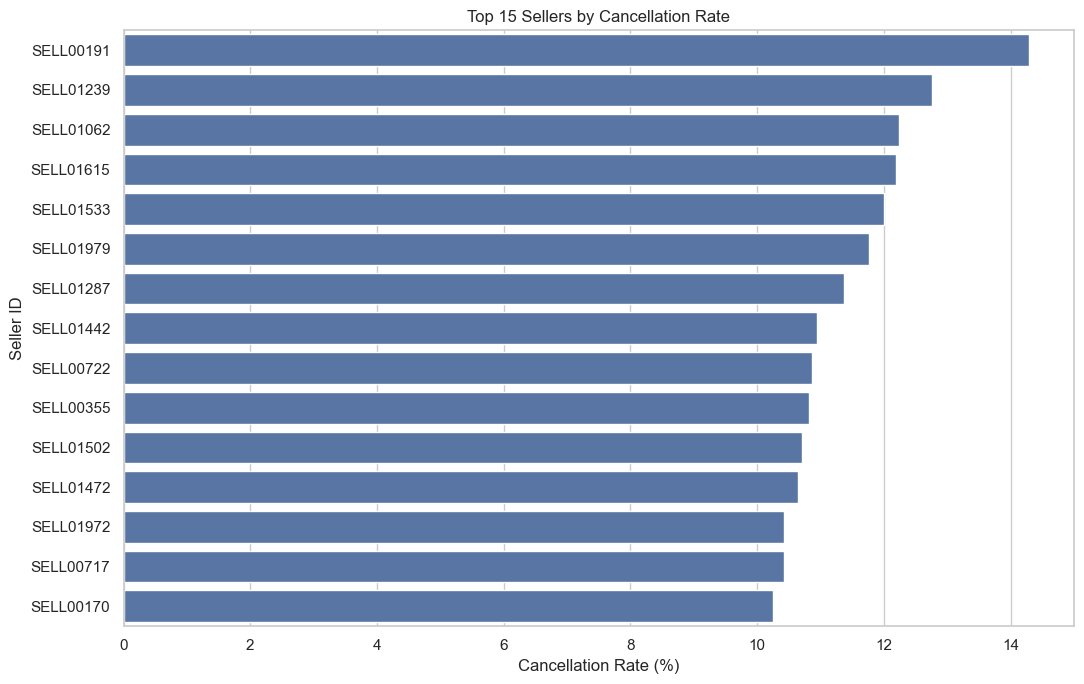

In [27]:
if seller_status_performance["Cancellation_Rate_%"].notna().any():
    plot_data = (
        seller_status_performance
        .sort_values("Cancellation_Rate_%", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(11, 7))

    sns.barplot(
        data=plot_data,
        x="Cancellation_Rate_%",
        y="SellerID"
    )

    plt.title("Top 15 Sellers by Cancellation Rate")
    plt.xlabel("Cancellation Rate (%)")
    plt.ylabel("Seller ID")

    plt.tight_layout()
    plt.show()
else:
    print("Cancelled status is not available in the dataset.")


## 14. Seller Sales vs Order Volume

The scatter plot identifies sellers that combine high order activity with high sales value.

Bubble size represents units sold.


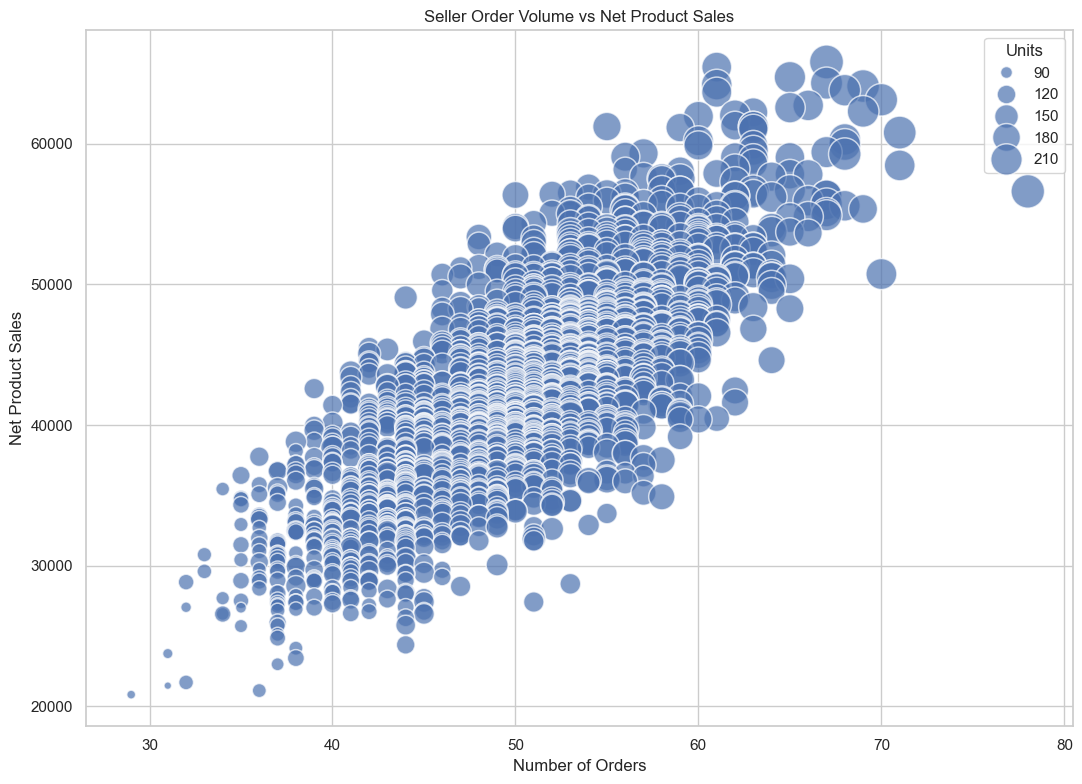

In [28]:
seller_sales_volume = seller_summary.copy()

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=seller_sales_volume,
    x="Orders",
    y="NetProductSales",
    size="Units",
    alpha=0.7,
    sizes=(30, 600)
)

plt.title("Seller Order Volume vs Net Product Sales")
plt.xlabel("Number of Orders")
plt.ylabel("Net Product Sales")

plt.tight_layout()
plt.show()


## 15. Seller Customer Reach vs Sales

This comparison helps distinguish sellers with broad customer reach from sellers whose sales are concentrated across fewer customers.


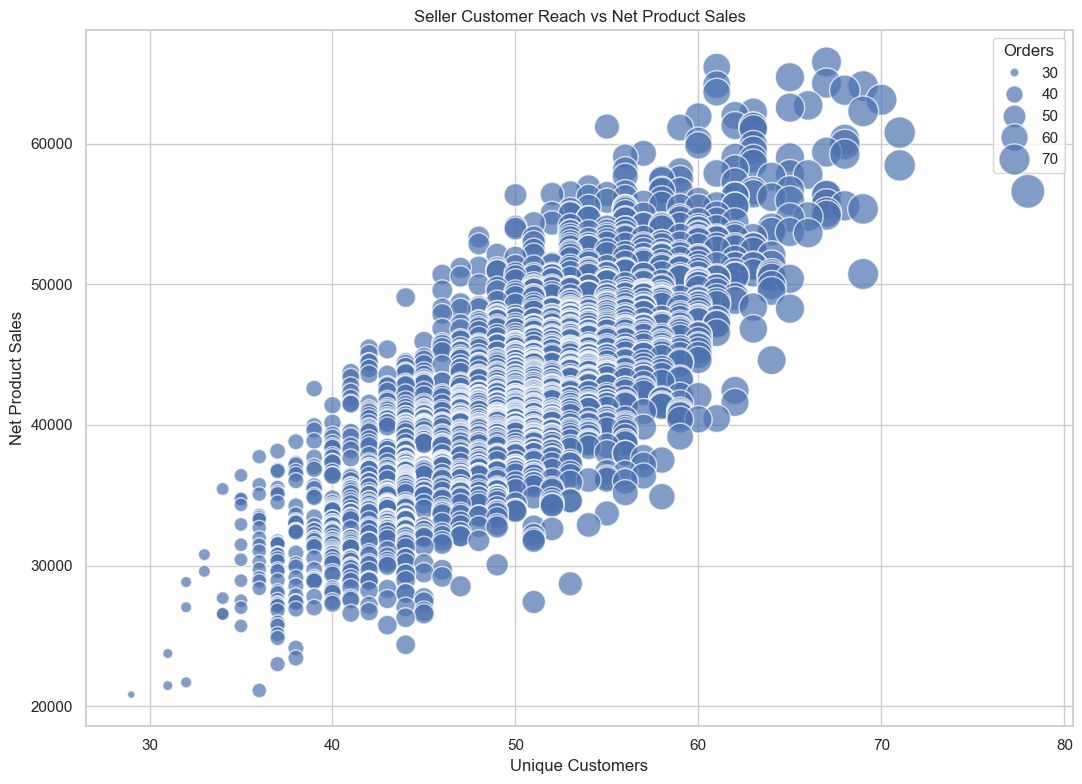

In [29]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=seller_summary,
    x="Customers",
    y="NetProductSales",
    size="Orders",
    alpha=0.7,
    sizes=(30, 600)
)

plt.title("Seller Customer Reach vs Net Product Sales")
plt.xlabel("Unique Customers")
plt.ylabel("Net Product Sales")

plt.tight_layout()
plt.show()


## 16. Top Sellers by Category

This section identifies the leading seller within each category based on net product sales.


In [30]:
seller_category_sales = (
    df.groupby(
        ["Category", "SellerID"]
    )
    .agg(
        Orders=("OrderID", "nunique"),
        Units=("Quantity", "sum"),
        NetProductSales=("NetProductSales", "sum")
    )
    .reset_index()
)

top_seller_by_category = (
    seller_category_sales
    .sort_values(
        ["Category", "NetProductSales"],
        ascending=[True, False]
    )
    .groupby("Category")
    .head(1)
    .reset_index(drop=True)
)

top_seller_by_category


,Category,SellerID,Orders,Units,NetProductSales
0,Books,SELL00251,17,59,18936.6855
1,Clothing,SELL01013,16,55,19586.7980
2,Electronics,SELL01225,14,50,18782.7740
3,Home & Kitchen,SELL00576,16,60,17923.2390
4,Sports & Outdoors,SELL01886,16,62,24085.9690
5,Toys & Games,SELL01140,15,49,19624.9060


## 17. Seller Category Concentration

The number of categories handled by each seller is compared with sales performance.

This helps identify broad-market sellers versus category-focused sellers.


In [31]:
seller_category_concentration = (
    seller_summary[
        [
            "SellerID",
            "Categories",
            "Products",
            "NetProductSales",
            "Orders",
            "Customers"
        ]
    ]
    .sort_values("NetProductSales", ascending=False)
)

seller_category_concentration.head(20)


,SellerID,Categories,Products,NetProductSales,Orders,Customers
805,SELL00806,6,37,65834.2080,67,67
439,SELL00440,6,34,65467.9530,61,61
220,SELL00221,6,37,64746.1560,65,65
1121,SELL01122,6,37,64326.7825,67,67
1224,SELL01225,6,37,64222.3260,61,61
708,SELL00709,6,39,64120.9305,69,69
811,SELL00812,6,36,63823.1925,68,68
993,SELL00994,6,35,63682.7285,61,61
535,SELL00536,6,39,63145.1890,70,70
1921,SELL01922,6,38,62743.6375,66,66


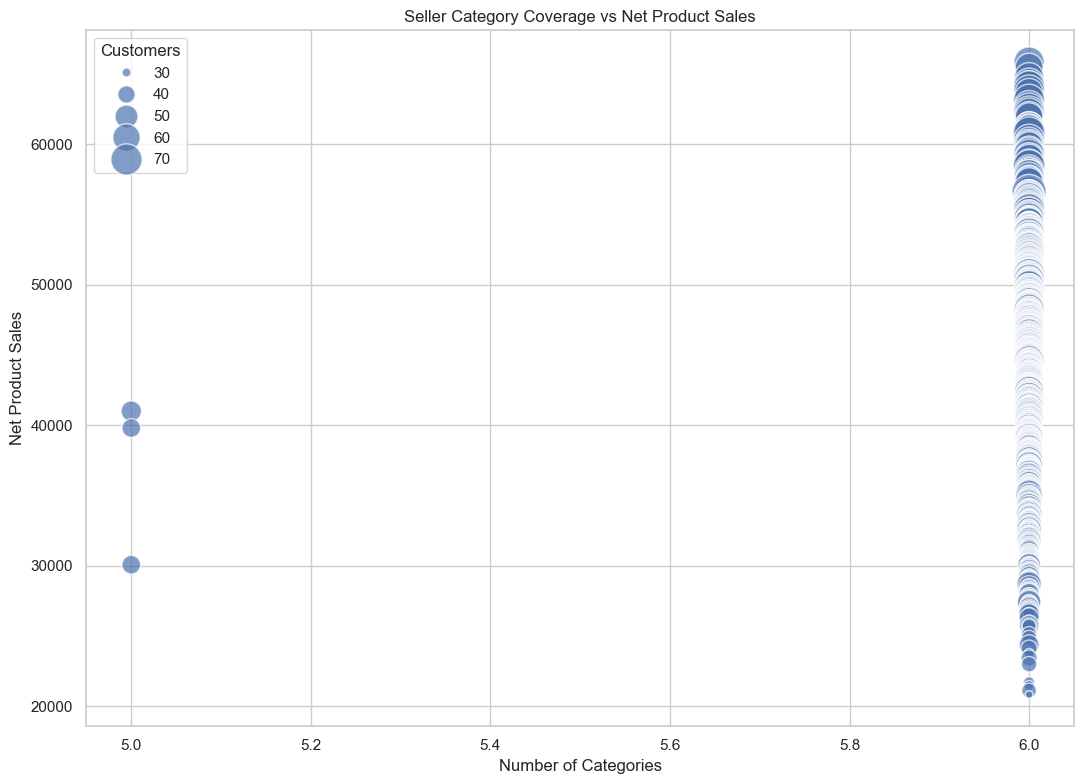

In [32]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=seller_category_concentration,
    x="Categories",
    y="NetProductSales",
    size="Customers",
    alpha=0.7,
    sizes=(30, 600)
)

plt.title("Seller Category Coverage vs Net Product Sales")
plt.xlabel("Number of Categories")
plt.ylabel("Net Product Sales")

plt.tight_layout()
plt.show()


## 18. Seller Concentration Analysis

Seller concentration measures how much of total net product sales is generated by the largest sellers.

This is useful for understanding whether sales are broadly distributed or dependent on a relatively small seller group.


In [33]:
seller_ranked = (
    seller_summary
    .sort_values("NetProductSales", ascending=False)
    .reset_index(drop=True)
)

seller_ranked["Seller_Rank"] = seller_ranked.index + 1

seller_ranked["Cumulative_Sales_Share_%"] = (
    seller_ranked["NetProductSales"].cumsum()
    / seller_ranked["NetProductSales"].sum()
    * 100
)

seller_ranked[
    [
        "Seller_Rank",
        "SellerID",
        "NetProductSales",
        "Sales_Share_%",
        "Cumulative_Sales_Share_%"
    ]
].head(20)


,Seller_Rank,SellerID,NetProductSales,Sales_Share_%,Cumulative_Sales_Share_%
0,1,SELL00806,65834.2080,0.078153,0.078153
1,2,SELL00440,65467.9530,0.077718,0.155870
2,3,SELL00221,64746.1560,0.076861,0.232731
3,4,SELL01122,64326.7825,0.076363,0.309094
4,5,SELL01225,64222.3260,0.076239,0.385333
5,6,SELL00709,64120.9305,0.076119,0.461452
6,7,SELL00812,63823.1925,0.075765,0.537217
7,8,SELL00994,63682.7285,0.075598,0.612816
8,9,SELL00536,63145.1890,0.074960,0.687776
9,10,SELL01922,62743.6375,0.074484,0.762260


In [34]:
top_5_sales_share = (
    seller_ranked.head(5)["NetProductSales"].sum()
    / seller_ranked["NetProductSales"].sum()
    * 100
)

top_10_sales_share = (
    seller_ranked.head(10)["NetProductSales"].sum()
    / seller_ranked["NetProductSales"].sum()
    * 100
)

top_20_sales_share = (
    seller_ranked.head(20)["NetProductSales"].sum()
    / seller_ranked["NetProductSales"].sum()
    * 100
)

concentration_summary = pd.DataFrame({
    "Seller Group": [
        "Top 5 Sellers",
        "Top 10 Sellers",
        "Top 20 Sellers"
    ],
    "Share of Net Product Sales (%)": [
        top_5_sales_share,
        top_10_sales_share,
        top_20_sales_share
    ]
})

concentration_summary


,Seller Group,Share of Net Product Sales (%)
0,Top 5 Sellers,0.385333
1,Top 10 Sellers,0.762260
2,Top 20 Sellers,1.495118


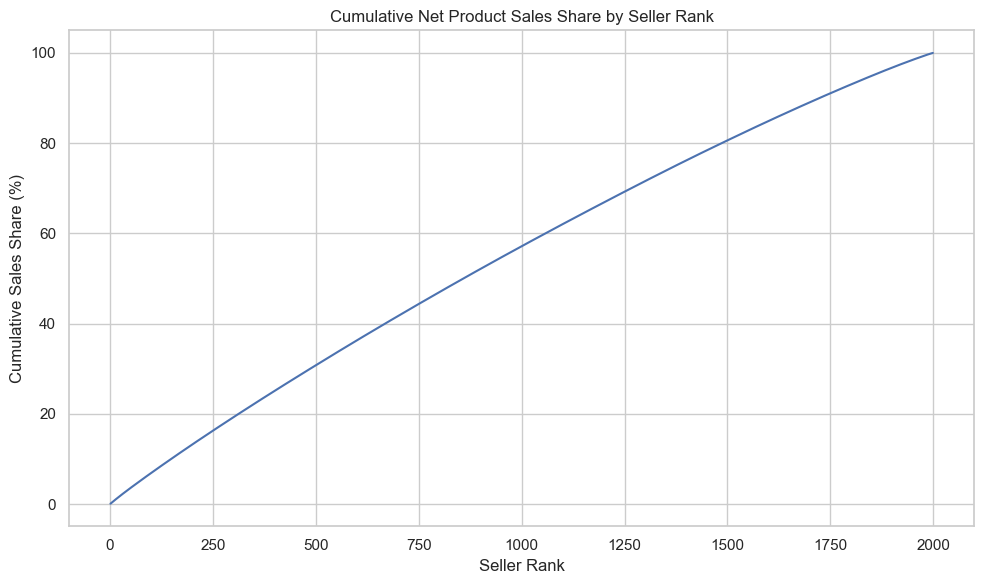

In [35]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=seller_ranked,
    x="Seller_Rank",
    y="Cumulative_Sales_Share_%"
)

plt.title("Cumulative Net Product Sales Share by Seller Rank")
plt.xlabel("Seller Rank")
plt.ylabel("Cumulative Sales Share (%)")

plt.tight_layout()
plt.show()


## 19. Seller Performance Tiers

A simple analytical tiering system is created using seller net product sales.

- **Top Tier:** top 10% of sellers
- **Strong:** next 20%
- **Standard:** next 40%
- **Developing:** remaining sellers

These are analytical segments created for this project and are not official business classifications.


In [36]:
n_sellers = len(seller_ranked)

seller_ranked["Performance_Tier"] = pd.qcut(
    seller_ranked["Seller_Rank"],
    q=[0, 0.10, 0.30, 0.70, 1.00],
    labels=[
        "Top Tier",
        "Strong",
        "Standard",
        "Developing"
    ],
    duplicates="drop"
)

tier_summary = (
    seller_ranked.groupby("Performance_Tier", observed=True)
    .agg(
        Sellers=("SellerID", "count"),
        Orders=("Orders", "sum"),
        Units=("Units", "sum"),
        Customers=("Customers", "sum"),
        NetProductSales=("NetProductSales", "sum"),
        Average_Discount=("Average_Discount", "mean"),
        Average_Order_Value=("Average_Order_Value", "mean")
    )
    .reset_index()
)

tier_summary


,Performance_Tier,Sellers,Orders,Units,Customers,NetProductSales,Average_Discount,Average_Order_Value
0,Top Tier,200,11842,36953,11836,1.113966e+07,0.073585,1029.710355
1,Strong,400,21925,67000,21912,1.944668e+07,0.072733,971.671599
2,Standard,799,40040,120182,40018,3.355334e+07,0.074649,919.821333
3,Developing,600,26193,76005,26180,2.009841e+07,0.074667,842.786427


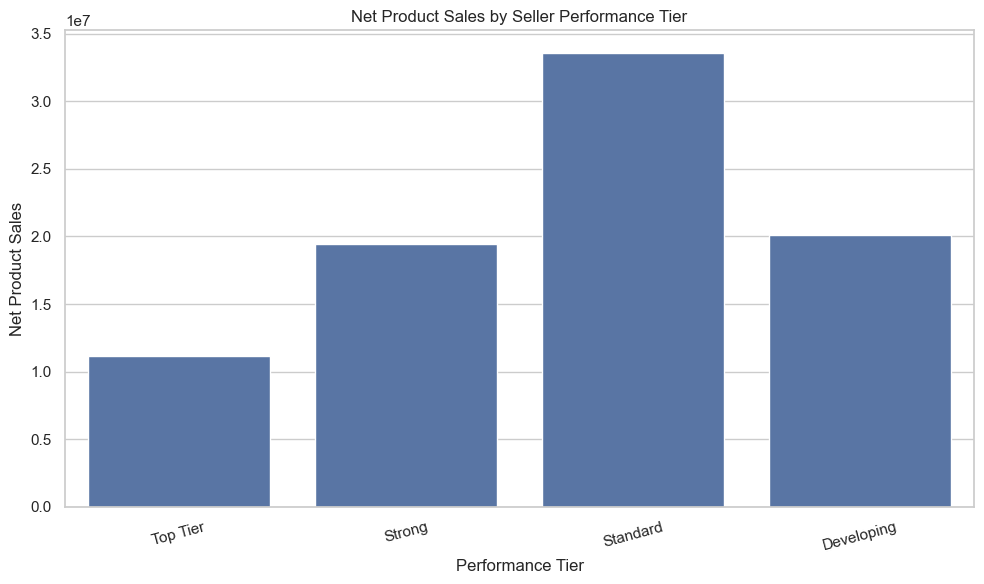

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=tier_summary,
    x="Performance_Tier",
    y="NetProductSales"
)

plt.title("Net Product Sales by Seller Performance Tier")
plt.xlabel("Performance Tier")
plt.ylabel("Net Product Sales")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


## 20. Multi-Metric Seller Score

A composite analytical score is created to identify sellers that perform consistently across several observable metrics.

The score uses percentile ranks for:

- Net Product Sales
- Orders
- Units Sold
- Customer Reach
- Product Diversity

Each metric receives equal weight.

This score is **not a financial profitability score** and should be used only as a comparative analytics measure.


In [38]:
score_columns = [
    "NetProductSales",
    "Orders",
    "Units",
    "Customers",
    "Products"
]

scored_sellers = seller_summary[
    ["SellerID"] + score_columns
].copy()

for column in score_columns:
    scored_sellers[f"{column}_Percentile"] = (
        scored_sellers[column].rank(pct=True) * 100
    )

percentile_columns = [
    f"{column}_Percentile"
    for column in score_columns
]

scored_sellers["Seller_Performance_Score"] = (
    scored_sellers[percentile_columns].mean(axis=1)
)

scored_sellers = scored_sellers.sort_values(
    "Seller_Performance_Score",
    ascending=False
)

scored_sellers.head(15)


,SellerID,NetProductSales,Orders,Units,Customers,Products,NetProductSales_Percentile,Orders_Percentile,Units_Percentile,Customers_Percentile,Products_Percentile,Seller_Performance_Score
535,SELL00536,63145.1890,70,220,70,39,99.599800,99.824912,99.774887,99.849925,98.999500,99.609805
708,SELL00709,64120.9305,69,223,69,39,99.749875,99.699850,99.849925,99.724862,98.999500,99.604802
1240,SELL01241,59958.4410,68,214,68,40,98.799400,99.499750,99.649825,99.499750,99.724862,99.434717
1334,SELL01335,58474.0190,71,205,71,40,98.199100,99.924962,98.949475,99.924962,99.724862,99.344672
3,SELL00004,59418.8770,67,209,67,39,98.599300,99.174587,99.299650,99.174587,98.999500,99.049525
263,SELL00264,55600.8405,68,204,68,44,96.148074,99.499750,98.774387,99.499750,100.000000,98.784392
1921,SELL01922,62743.6375,66,204,66,38,99.549775,98.849425,98.774387,98.874437,97.573787,98.724362
1583,SELL01584,62315.1155,69,213,69,37,99.449725,99.699850,99.574787,99.724862,94.972486,98.684342
805,SELL00806,65834.2080,67,234,67,37,100.000000,99.174587,100.000000,99.174587,94.972486,98.664332
346,SELL00347,55740.4550,67,213,67,39,96.298149,99.174587,99.574787,99.174587,98.999500,98.644322


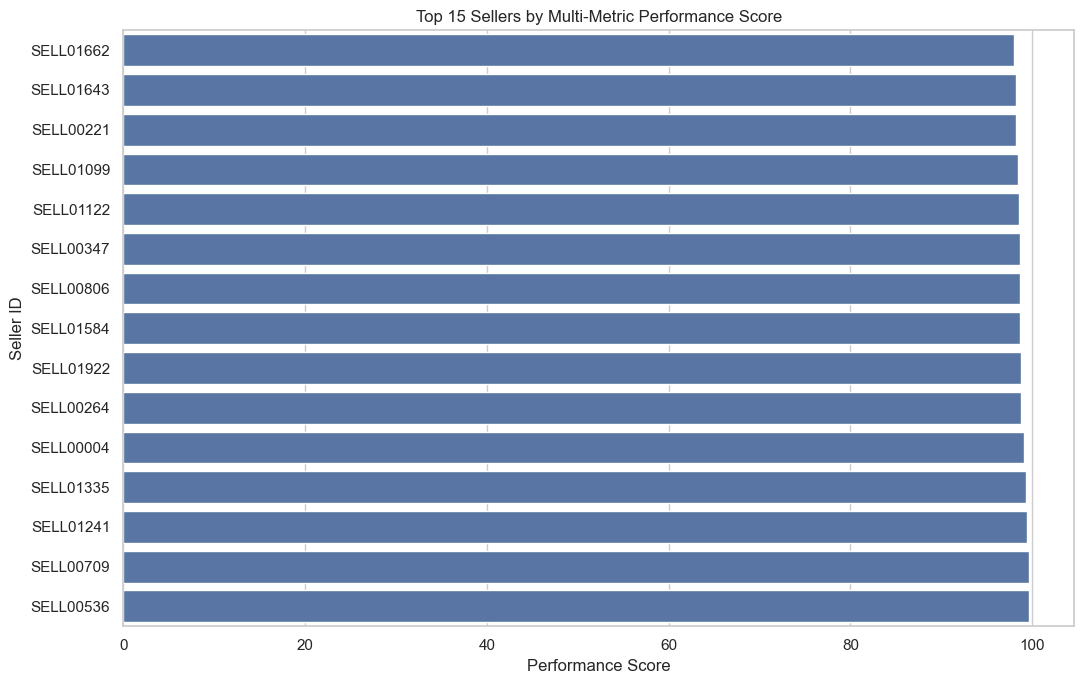

In [39]:
top_overall_sellers = (
    scored_sellers
    .head(15)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_overall_sellers.sort_values("Seller_Performance_Score"),
    x="Seller_Performance_Score",
    y="SellerID"
)

plt.title("Top 15 Sellers by Multi-Metric Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()


## 21. Seller Performance Heatmap

The heatmap compares the strongest sellers across normalized performance dimensions.

Percentile ranks are used so that variables with different units can be compared on a common 0–100 scale.


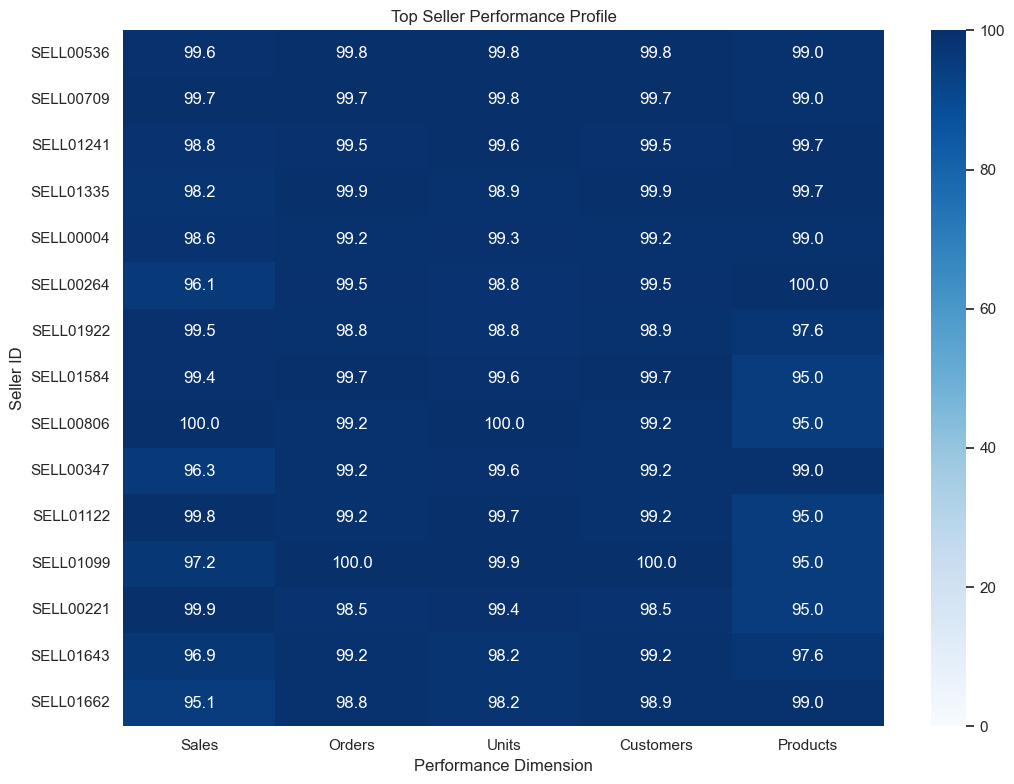

In [40]:
heatmap_data = (
    scored_sellers
    .head(15)
    .set_index("SellerID")[percentile_columns]
    .rename(columns={
        "NetProductSales_Percentile": "Sales",
        "Orders_Percentile": "Orders",
        "Units_Percentile": "Units",
        "Customers_Percentile": "Customers",
        "Products_Percentile": "Products"
    })
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title("Top Seller Performance Profile")
plt.xlabel("Performance Dimension")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()


## 22. Business Questions — Direct Answers

The following cells identify the leading sellers for the major seller-performance metrics.


In [41]:
best_sales_seller = seller_summary.loc[
    seller_summary["NetProductSales"].idxmax()
]

best_order_seller = seller_summary.loc[
    seller_summary["Orders"].idxmax()
]

best_units_seller = seller_summary.loc[
    seller_summary["Units"].idxmax()
]

best_customer_seller = seller_summary.loc[
    seller_summary["Customers"].idxmax()
]

best_aov_seller = seller_summary.loc[
    seller_summary["Average_Order_Value"].idxmax()
]

best_discount_seller = seller_summary.loc[
    seller_summary["Weighted_Discount_%"].idxmax()
]

print(
    f"Highest net product sales seller: "
    f"{best_sales_seller['SellerID']} "
    f"(${best_sales_seller['NetProductSales']:,.2f})"
)

print(
    f"Highest order-volume seller: "
    f"{best_order_seller['SellerID']} "
    f"({int(best_order_seller['Orders']):,} orders)"
)

print(
    f"Highest units-sold seller: "
    f"{best_units_seller['SellerID']} "
    f"({int(best_units_seller['Units']):,} units)"
)

print(
    f"Highest customer-reach seller: "
    f"{best_customer_seller['SellerID']} "
    f"({int(best_customer_seller['Customers']):,} customers)"
)

print(
    f"Highest average-order-value seller: "
    f"{best_aov_seller['SellerID']} "
    f"(${best_aov_seller['Average_Order_Value']:,.2f})"
)

print(
    f"Highest weighted-discount seller: "
    f"{best_discount_seller['SellerID']} "
    f"({best_discount_seller['Weighted_Discount_%']:.2f}%)"
)


Highest net product sales seller: SELL00806 ($65,834.21)
Highest order-volume seller: SELL01099 (78 orders)
Highest units-sold seller: SELL00806 (234 units)
Highest customer-reach seller: SELL01099 (78 customers)
Highest average-order-value seller: SELL00342 ($1,231.02)
Highest weighted-discount seller: SELL01747 (13.82%)


## 23. Final Seller Insights

### Sales Performance
The seller ranking identifies the sellers contributing the largest amount of net product sales.

### Volume Performance
Order and unit rankings reveal sellers that operate at high transaction volume, which may differ from the sales-value ranking.

### Customer Reach
Unique customer counts provide an additional measure of market reach.

### Product Diversity
Product, brand, and category counts distinguish broad sellers from specialists.

### Discount Behavior
Weighted discount rates show which sellers rely more heavily on discounting. High discounting should not be interpreted as high or low profitability because seller costs are unavailable.

### Operational Performance
Delivery and cancellation rates provide a basic operational view when the corresponding order statuses are present.

### Seller Concentration
Cumulative sales share shows whether the business depends heavily on a small group of sellers.

### Composite Performance
The multi-metric score provides a balanced comparison across sales, volume, customers, and product diversity. It should be treated as an analytical ranking rather than an official seller score.

### Data Limitation
The dataset does not provide seller ratings, seller costs, commissions, returns, customer reviews, inventory levels, fulfillment time, or profit. Therefore, the analysis cannot determine true seller profitability or service quality.


## 24. Export Seller Analysis Outputs

The key seller-level tables are exported for reuse in the SQL and Power BI stages of the project.


In [42]:
output_dir = Path("../data/seller_analysis_outputs")

output_dir.mkdir(parents=True, exist_ok=True)

seller_overview.to_csv(
    output_dir / "seller_overview.csv",
    index=False
)

seller_summary.to_csv(
    output_dir / "seller_summary.csv",
    index=False
)

seller_status_performance.to_csv(
    output_dir / "seller_status_performance.csv",
    index=False
)

seller_category_sales.to_csv(
    output_dir / "seller_category_sales.csv",
    index=False
)

top_seller_by_category.to_csv(
    output_dir / "top_seller_by_category.csv",
    index=False
)

seller_ranked.to_csv(
    output_dir / "seller_ranked_concentration.csv",
    index=False
)

concentration_summary.to_csv(
    output_dir / "seller_concentration_summary.csv",
    index=False
)

tier_summary.to_csv(
    output_dir / "seller_performance_tiers.csv",
    index=False
)

scored_sellers.to_csv(
    output_dir / "seller_performance_score.csv",
    index=False
)

print("Seller analysis outputs exported successfully.")
print("Output directory:", output_dir)


Seller analysis outputs exported successfully.
Output directory: ..\data\seller_analysis_outputs


# 25. Conclusion

This notebook evaluated seller performance across the e-commerce dataset using sales, volume, customer reach, pricing, discounting, product diversity, and order-status metrics.

The analysis covered:

- Seller sales ranking
- Order and unit volume
- Customer reach
- Average order value
- Discount behavior
- Product and category diversity
- Delivery and cancellation performance
- Seller concentration
- Category-level seller leadership
- Seller performance tiers
- Multi-metric seller scoring

The results provide a seller-focused view of the marketplace and establish the foundation for the next stages of the project.
